SAM1 code based on https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
and https://github.com/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb

SAM2 code based on https://github.com/huggingface/segment-anything-2/blob/coreml-conversion/notebooks/image_predictor_example.ipynb
and https://github.com/huggingface/segment-anything-2/blob/coreml-conversion/notebooks/automatic_mask_generator_example.ipynb

In [1]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch

print("CHECKING DEVICES")
if torch.backends.mps.is_available():
   device = torch.device("mps")
   # SAM still does not fix the problems related MPS till 2026.4.10
   print("MPS is ready")
   # Support for MPS is preliminary.

elif torch.cuda.is_available():
   device = torch.device("cuda")
   print("CUDA is ready for use")

else:
   device = torch.device("cpu")
   print("CPU is ready for use")

print(f"Final device selected: {device}\n")

CHECKING DEVICES
CUDA is ready for use
Final device selected: cuda



In [2]:
# set up the environment when using colab
# set using_colab to true when using the colab
using_colab = True

if using_colab:
    import torch
    import torchvision

    from google.colab import drive
    drive.mount('/content/drive')

    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
    !cp /content/sam_vit_h_4b8939.pth /content/drive/MyDrive/sam_vit_h_4b8939.pth

    # use ViT-B(base) for video demo
    # for saving time and computing resources
    # !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    # !cp /content/sam_vit_b_01ec64.pth /content/drive/MyDrive/sam_vit_b_01ec64.pth

    # ViT-L
    # !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth
    # !cp /content/sam_vit_l_0b3195.pth /content/drive/MyDrive/sam_vit_l_0b3195.pth

    ### SAM 2
    # !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    # !wget https://github.com/huggingface/segment-anything-2/blob/coreml-conversion/sam2/configs/sam2.1/sam2.1_hiera_l.yaml
    # !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

Mounted at /content/drive
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-izxa6i3p
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-izxa6i3p
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=9996c49359b7c227e91bc2543fcad2099c57a0198784ff9890fcbd5cedca9e13
  Stored in directory: /tmp/pip-ephem-wheel-cache-3cqusmul/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
--2026-04-17 13:30:57--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.

In [3]:
# import other libraries that is neeeded
import cv2 as cv
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

import warnings
warnings.filterwarnings("ignore")

In [4]:
# read and load the images
# change the path addresses
test_path = '/content/drive/MyDrive/9517/EWS-Dataset/test'
train_path = '/content/drive/MyDrive/9517/EWS-Dataset/train'
val_path = '/content/drive/MyDrive/9517/EWS-Dataset/validation'

def load_images(path):
    all_files = os.listdir(path)
    png_files = sorted([f for f in all_files if f.lower().endswith('.png')])
    # mask file are files end with "_mask.png"
    # filter out the original images
    image_files = [f for f in png_files if not f.lower().endswith('_mask.png')]

    images = []
    masks = []
    # filenames = []

    for fname in image_files:
        img_path = os.path.join(path, fname)

        mask_name = fname.replace('.png', '_mask.png')
        mask_path = os.path.join(path, mask_name)

        img = cv.imread(img_path, cv.IMREAD_COLOR)
        mask = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)

        if img is not None and mask is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

            images.append(img)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)

    return images, masks


# Load all sets
test_images, test_masks  = load_images(test_path)
train_images, train_masks = load_images(train_path)
val_images, val_masks = load_images(val_path)

print("Test images shape: ", test_images.shape, test_masks.shape)
print("Train images shape:", train_images.shape, train_masks.shape)
print("Validation images shape:  ", val_images.shape, val_masks.shape)

Test images shape:  (24, 350, 350, 3) (24, 350, 350)
Train images shape: (142, 350, 350, 3) (142, 350, 350)
Validation images shape:   (24, 350, 350, 3) (24, 350, 350)


In [5]:
def compute_metrics(pred_mask, gt_mask):
    pred = (pred_mask > 0).flatten()
    gt   = (gt_mask > 0).flatten()

    accuracy  = accuracy_score(gt, pred)
    precision = precision_score(gt, pred)
    recall = recall_score(gt, pred)
    f1 = f1_score(gt, pred)

    # Compute Intersection-over-Union between two binary mask
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    iou = intersection / union if union > 0 else 0.0

    return accuracy, precision, recall, f1, iou

In [6]:
# SAM 1
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [7]:
# SAM 1
# load the pre-trained model vit
# choose an approprate vit for your device
# change the pth file path where you store

#model_type = "vit_l" # large
#sam_checkpoint = "/content/drive/MyDrive/sam_vit_l_0b3195.pth"

# model_type = "vit_b" # base
# sam_checkpoint = "/content/drive/MyDrive/sam_vit_b_01ec64.pth"

model_type = "vit_h" # huge
sam_checkpoint = "/content/drive/MyDrive/sam_vit_h_4b8939.pth" # change the path where you store

#  MPS does not support float64, force to use float32
if str(device) == "mps":
    device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Model predicts the masks automaticly
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=250,
)

# run SAM automatic mask generation and return a binary mask
def predict_sam_mask(image):
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)

    try:
        masks = mask_generator.generate(image)
    except (IndexError, RuntimeError):
        return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    if len(masks) == 0:
        return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

    # conbine all instance masks
    combined = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
    for m in masks:
        combined = np.logical_or(combined, m['segmentation'])

    return combined.astype(np.uint8) * 255

In [8]:
def evaluation(images, gt_masks, set_name="Validation", predict_fn=None):
    if predict_fn is None:
        predict_fn = predict_sam_mask
    pred_masks = []
    for i, img in enumerate(images):
        pred = predict_fn(img)
        pred_masks.append(pred)
    pred_masks = np.array(pred_masks)

    acc_list, prec_list, rec_list, f1_list, iou_list = [], [], [], [], []
    for pred, gt in zip(pred_masks, gt_masks):
      if pred.shape != gt.shape:
          gt = cv.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv.INTER_NEAREST)
      a, p, r, f, i = compute_metrics(pred, gt)

      acc_list.append(a)
      prec_list.append(p)
      rec_list.append(r)
      f1_list.append(f)
      iou_list.append(i)

    print(f"\nSAM (vit_h) Zero-Shot on {set_name}")
    #print(f"\nSAM (vit_l) Zero-Shot on {set_name}")
    #print(f"\nSAM (vit_b) Zero-Shot on {set_name}")
    print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall    : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    print(f"F1-score  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"IoU       : {np.mean(iou_list):.4f} ± {np.std(iou_list):.4f}")
    return pred_masks

In [9]:
# zero-shot evaluation on val
val_pred_masks = evaluation(val_images, val_masks, "Validation")


SAM (vit_h) Zero-Shot on Validation
Accuracy  : 0.6668 ± 0.2647
Precision : 0.6790 ± 0.2729
Recall    : 0.9302 ± 0.1813
F1-score  : 0.7515 ± 0.2269
IoU       : 0.6530 ± 0.2833


In [10]:
# SAM 2
#from sam2.build_sam import build_sam2
#from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [11]:
# SAM2
#model_cfg = "/Users/leety/Desktop/9517/Proj/SAM2/configs/sam2.1/sam2.1_hiera_b+.yaml"
#sam2_checkpoint = "/Users/leety/Desktop/9517/Proj/SAM2/checkpoints/sam2.1_hiera_base_plus.pt"

#model_cfg = "/Users/leety/Desktop/9517/Proj/SAM2/configs/sam2.1/sam2.1_hiera_l.yaml"
#sam2_checkpoint = "/Users/leety/Desktop/9517/Proj/SAM2/checkpoints/sam2.1_hiera_large.pt"

#model_cfg = "/Users/leety/Desktop/9517/Proj/SAM2/configs/sam2.1/sam2.1_hiera_s.yaml"
#sam2_checkpoint = "/Users/leety/Desktop/9517/Proj/SAM2/checkpoints/sam2.1_hiera_small.pt"

#model_cfg = "/Users/leety/Desktop/9517/Proj/SAM2/configs/sam2.1/sam2.1_hiera_t.yaml"
#sam2_checkpoint = "/Users/leety/Desktop/9517/Proj/SAM2/checkpoints/sam2.1_hiera_tiny.pt"

#sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
#mask_generator_2 = SAM2AutomaticMaskGenerator(
#     model=sam2_model,
#     points_per_side=32,
#     points_per_batch=100,
#     pred_iou_thresh=0.7,
#     stability_score_thresh=0.92,
#     stability_score_offset=0.7,
#     crop_n_layers=1,
#     box_nms_thresh=0.7,
#     crop_n_points_downscale_factor=2,
#     min_mask_region_area=250,
#     use_m2m=True,
# )

# run SAM automatic mask generation and return a binary mask
# def predict_sam2_mask(image):
#     if image.dtype != np.uint8:
#         image = image.astype(np.uint8)
#     masks2 = mask_generator_2.generate(image)

#     if len(masks2) == 0:
#         return np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

#     # conbine all instance masks2
#     combined = np.zeros((image.shape[0], image.shape[1]), dtype=bool)
#     for m in masks2:
#         combined = np.logical_or(combined, m['segmentation'])

#     return combined.astype(np.uint8) * 255

In [12]:
# def evaluation2(images, gt_masks, set_name="Validation"):
#     pred_masks = []
#     for i, img in enumerate(images):
#         pred = predict_sam2_mask(img)
#         pred_masks.append(pred)
#     pred_masks = np.array(pred_masks)

#     acc_list, prec_list, rec_list, f1_list, iou_list = [], [], [], [], []
#     for pred, gt in zip(pred_masks, gt_masks):
#         a, p, r, f, i = compute_metrics(pred, gt)
#         acc_list.append(a)
#         prec_list.append(p)
#         rec_list.append(r)
#         f1_list.append(f)
#         iou_list.append(i)

#     print(f"\nSAM2 (vit_h) Zero-Shot on {set_name}")
#     print(f"\nSAM2 (vit_l) Zero-Shot on {set_name}")
#     print(f"\nSAM2 (vit_b) Zero-Shot on {set_name}")
#     print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
#     print(f"Precision : {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
#     print(f"Recall    : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
#     print(f"F1-score  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
#     print(f"IoU       : {np.mean(iou_list):.4f} ± {np.std(iou_list):.4f}")
#     return pred_masks

# val_pred_masks2 = evaluation2(val_images, val_masks, "Validation")

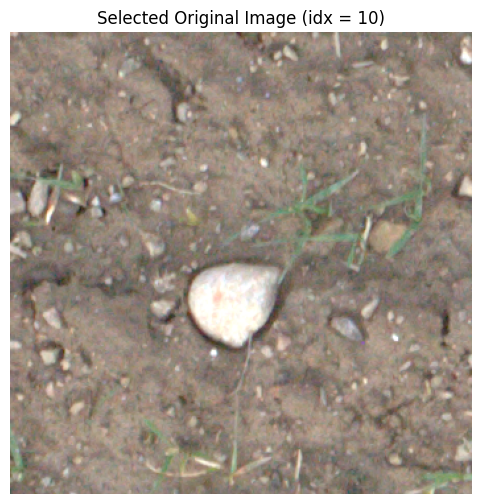

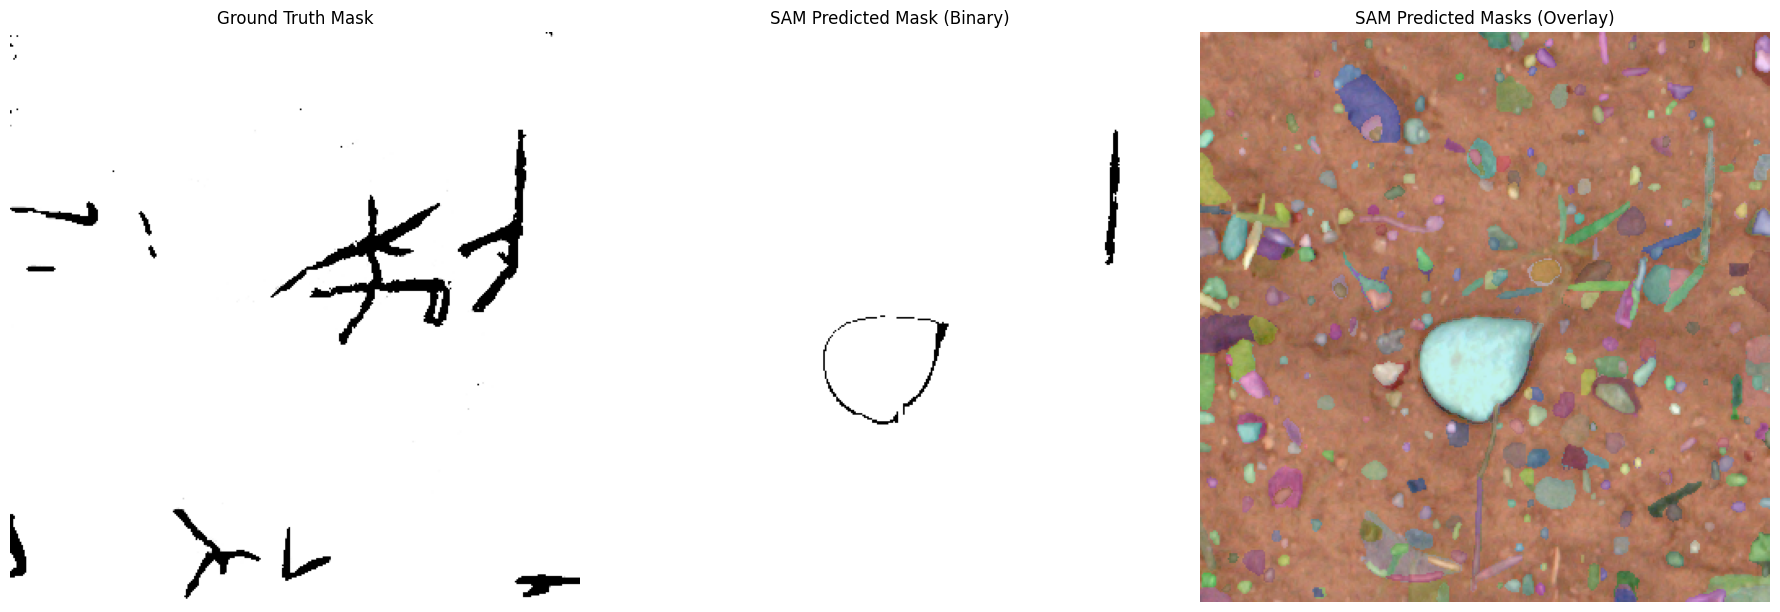

In [13]:
# compare the ground truth mask and predicted mask visually.
# pick up an image randmly to compare
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

idx = random.randint(0, len(val_images)-1)
img = val_images[idx]
gt  = val_masks[idx]
pred = predict_sam_mask(img)

anns = mask_generator.generate(img.astype(np.uint8) if img.dtype != np.uint8 else img)

# display the chose picture
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Selected Original Image (idx = {idx})")
plt.axis('off')
plt.show()

# GT Mask vs Predicted Mask visually
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(gt, cmap='gray')
ax[0].set_title("Ground Truth Mask")
ax[0].axis('off')

ax[1].imshow(pred, cmap='gray')
ax[1].set_title("SAM Predicted Mask (Binary)")
ax[1].axis('off')

# overlay
ax[2].imshow(img)
show_anns(anns)
ax[2].set_title("SAM Predicted Masks (Overlay)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# LoRA for SAM1
# https://mbrenndoerfer.com/writing/lora-implementation-pytorch-peft-guide
import torch.nn as nn

class LoRASAM(nn.Module):
    def __init__(self, module, dim, rank=4):
        super().__init__()
        self.module = module

        self.A = nn.Parameter(torch.randn(dim, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, dim * 3))  # qkv → 3*dim

    def forward(self, x):
        return self.module(x) + x @ self.A @ self.B

# Query Key Value
# Inject into the QKV
for block in sam.image_encoder.blocks:
    if not isinstance(block.attn.qkv, LoRASAM):
        dim = block.attn.proj.weight.shape[1]
        block.attn.qkv = LoRASAM(block.attn.qkv, dim)

sam.to(device)

if str(device) == "mps":
    sam = sam.float()

# freeze SAM all param
for p in sam.parameters():
    p.requires_grad = False
# unfreeze LoRA layer of image encoder
for block in sam.image_encoder.blocks:
    if isinstance(block.attn.qkv, LoRASAM):
        for p in block.attn.qkv.parameters():
            p.requires_grad = True
sam.train()

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): LoRASAM(
            (module): Linear(in_features=1280, out_features=3840, bias=True)
          )
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding

In [15]:
EPOCHS = 3 # for saving time
import torch.nn.functional as F

class SimpleDataset:
    def __init__(self, images, masks):
        self.images = [torch.from_numpy(i).permute(2,0,1).float()/255.0 for i in images]
        self.masks  = [torch.from_numpy(m).unsqueeze(0).float()/255.0 for m in masks]

    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.images[i], self.masks[i]

# freeze the encoder
for p in sam.parameters():
    p.requires_grad = False
# and only train the mask_decoder
for p in sam.mask_decoder.parameters():
    p.requires_grad = True

def forward_sam(img):
    # transform into sam need
    img = img * 255.0
    # padding
    img = sam.preprocess(img)

    with torch.no_grad():
        emb = sam.image_encoder(img)

    sparse, dense = sam.prompt_encoder(points=None, boxes=None, masks=None)

    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False,
    )

    masks = sam.postprocess_masks(
        low_res,
        input_size=img.shape[-2:],
        original_size=img.shape[-2:]
    )

    return masks[:, 0]

def loss_fn(logits, gt):
    if logits.dim() == 3:
        logits = logits.unsqueeze(1)
    if gt.dim() == 3:
        gt = gt.unsqueeze(1)
    gt = gt.float()

    gt = F.interpolate(gt, size=logits.shape[-2:], mode='nearest')

    bce = nn.BCEWithLogitsLoss()(logits, gt)

    pred = torch.sigmoid(logits)
    dice = 1 - (2*(pred*gt).sum() + 1) / (pred.sum() + gt.sum() + 1)

    return bce + dice

def train(images, masks):
    loader = torch.utils.data.DataLoader(
        SimpleDataset(images, masks), batch_size=1, shuffle=True
    )

    opt = torch.optim.AdamW(
        sam.mask_decoder.parameters(),
        lr=1e-4)

    sam.train()
    for e in range(EPOCHS):
        loss_sum = 0
        for img, gt in loader:
            img, gt = img.to(device), gt.to(device)

            opt.zero_grad()
            logits = forward_sam(img)
            loss = loss_fn(logits, gt)

            loss.backward()
            opt.step()
            loss_sum += loss.item()

        print(f"Epoch {e+1}: {loss_sum/len(loader):.4f}")

# 1. Direct Training
print("Direct Training")
train(train_images, train_masks)
torch.save(sam.image_encoder.state_dict(), "lora_direct.pth")

# 2. K-Fold Training
print("\nk-Fold Training, k = 5")

n = len(train_images)
idx = np.random.permutation(n)
fold_size = n // 5

for f in range(5):
    print(f"Fold {f+1}")

    val_idx = idx[f*fold_size:(f+1)*fold_size]
    train_idx = np.setdiff1d(idx, val_idx)

    train(train_images[train_idx], train_masks[train_idx])

torch.save(sam.image_encoder.state_dict(), "lora_kfold.pth")

def predict(image):
    img = torch.from_numpy(image).permute(2,0,1).float().unsqueeze(0)/255.0
    img = img.to(device)

    with torch.no_grad():
        logits = forward_sam(img)

    pred = torch.sigmoid(logits)

    return (pred[0].cpu().numpy() > 0.5).astype(np.uint8)*255

Direct Training
Epoch 1: 0.7828
Epoch 2: 0.7200
Epoch 3: 0.6962

k-Fold Training, k = 5
Fold 1
Epoch 1: 0.6635
Epoch 2: 0.6575
Epoch 3: 0.6413
Fold 2
Epoch 1: 0.6648
Epoch 2: 0.6545
Epoch 3: 0.6504
Fold 3
Epoch 1: 0.6415
Epoch 2: 0.6328
Epoch 3: 0.6370
Fold 4
Epoch 1: 0.6426
Epoch 2: 0.6382
Epoch 3: 0.6315
Fold 5
Epoch 1: 0.6575
Epoch 2: 0.6582
Epoch 3: 0.6562


In [16]:
# 3. Compare the 2 training methods on Val
sam.eval()

sam.image_encoder.load_state_dict(torch.load("lora_direct.pth"))
val_direct = evaluation(val_images, val_masks, "Direct")

sam.image_encoder.load_state_dict(torch.load("lora_kfold.pth"))
val_kfold = evaluation(val_images, val_masks, "K-Fold")

iou_d = np.mean([compute_metrics(p,g)[4] for p,g in zip(val_direct, val_masks)])
iou_k = np.mean([compute_metrics(p,g)[4] for p,g in zip(val_kfold, val_masks)])

print(f"\nDirect IoU: {iou_d:.4f}")
print(f"K-Fold IoU: {iou_k:.4f}")

if iou_d > iou_k:
    sam.image_encoder.load_state_dict(torch.load("lora_direct.pth"))
    Train_Model = "Direct"
else:
    sam.image_encoder.load_state_dict(torch.load("lora_kfold.pth"))
    Train_Model = "K-Fold"


SAM (vit_h) Zero-Shot on Direct
Accuracy  : 0.6993 ± 0.2570
Precision : 0.4440 ± 0.4556
Recall    : 0.5000 ± 0.5000
F1-score  : 0.4665 ± 0.4719
IoU       : 0.4440 ± 0.4556

SAM (vit_h) Zero-Shot on K-Fold
Accuracy  : 0.6993 ± 0.2570
Precision : 0.4440 ± 0.4556
Recall    : 0.5000 ± 0.5000
F1-score  : 0.4665 ± 0.4719
IoU       : 0.4440 ± 0.4556

Direct IoU: 0.4440
K-Fold IoU: 0.4440


In [17]:
# Test, for final report
test_pred_masks = evaluation(test_images, test_masks, f"TEST SET ({Train_Model})")


SAM (vit_h) Zero-Shot on TEST SET (K-Fold)
Accuracy  : 0.6302 ± 0.2518
Precision : 0.3595 ± 0.4358
Recall    : 0.4167 ± 0.4930
F1-score  : 0.3828 ± 0.4572
IoU       : 0.3595 ± 0.4358
